<a href="https://colab.research.google.com/github/HerinePamela/Notebook/blob/main/Wetland_conservation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/LULC.csv')

# Convert pixel count to area (hectares)
df['Area_ha'] = df['COUNT'] * 0.01

# Extract Year and Season
df[['Year','Season1','Season2']] = df['YEAR'].str.split('_', expand=True)
df['Season'] = df['Season1'] + '_' + df['Season2']

df = df[['LANDCLASS','Year','Season','Area_ha']]

print(df.head())

               LANDCLASS  Year      Season  Area_ha
0             Open_water  2025  Dry_Season    40.21
1               Built_up  2025  Dry_Season   159.15
2               Bareland  2025  Dry_Season   345.84
3               Farmland  2025  Dry_Season   927.20
4  Tarmac/black_surfaces  2025  Dry_Season   416.42


Aggregate Area by Land Class and Year


In [ ]:
summary = df.groupby(['Year','LANDCLASS'])['Area_ha'].sum().reset_index()

print(summary)

    Year              LANDCLASS  Area_ha
0   2015               Bareland   995.85
1   2015               Built_up   384.04
2   2015               Farmland  1471.35
3   2015             Open_water   477.11
4   2015  Tarmac/black_surfaces   473.48
5   2015             Vegetation  2170.11
6   2015                Wetland   438.55
7   2020               Bareland   841.96
8   2020               Built_up   752.84
9   2020               Farmland   975.95
10  2020             Open_water   223.80
11  2020  Tarmac/black_surfaces  1068.70
12  2020             Vegetation  2101.06
13  2020                Wetland   486.97
14  2025               Bareland  1135.98
15  2025               Built_up   353.11
16  2025               Farmland  1413.76
17  2025             Open_water    81.26
18  2025  Tarmac/black_surfaces  1074.48
19  2025             Vegetation  1939.59
20  2025                Wetland   453.08


Create a Land-Class Change Table

In [ ]:
pivot = summary.pivot(index='LANDCLASS', columns='Year', values='Area_ha')

pivot['Change_2015_2025'] = pivot['2025'] - pivot['2015']

print(pivot)

Year                      2015     2020     2025  Change_2015_2025
LANDCLASS                                                         
Bareland                995.85   841.96  1135.98            140.13
Built_up                384.04   752.84   353.11            -30.93
Farmland               1471.35   975.95  1413.76            -57.59
Open_water              477.11   223.80    81.26           -395.85
Tarmac/black_surfaces   473.48  1068.70  1074.48            601.00
Vegetation             2170.11  2101.06  1939.59           -230.52
Wetland                 438.55   486.97   453.08             14.53


Visualization 1 — Landclass Change (Bar Chart)

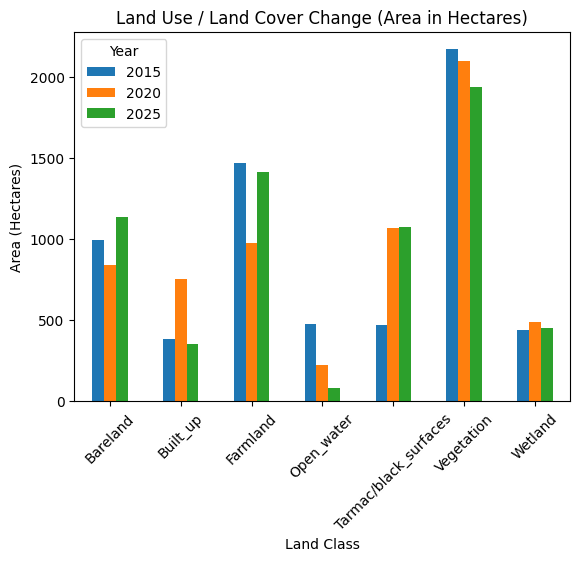

In [ ]:
import matplotlib.pyplot as plt

composition.T[['2015','2020','2025']].plot(kind='bar')

plt.title('Land Use / Land Cover Change (Area in Hectares)')
plt.ylabel('Area (Hectares)')
plt.xlabel('Land Class')
plt.xticks(rotation=45)

plt.show()

Visualization 2 — Wetland Trend

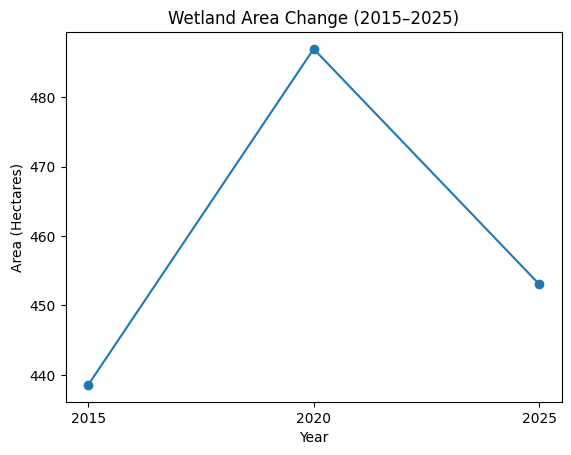

In [ ]:
wetland = summary[summary['LANDCLASS']=='Wetland']

plt.plot(wetland['Year'], wetland['Area_ha'], marker='o')

plt.title('Wetland Area Change (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Area (Hectares)')

plt.show()

Visualization 3 — Land Cover Composition

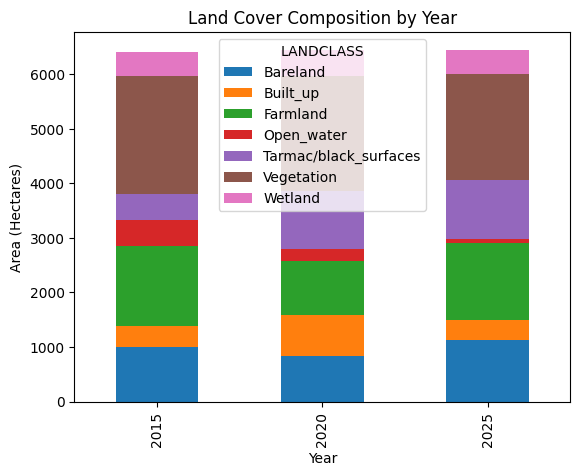

In [ ]:
composition = summary.pivot(index='Year', columns='LANDCLASS', values='Area_ha')

composition.plot(kind='bar', stacked=True)

plt.title('Land Cover Composition by Year')
plt.ylabel('Area (Hectares)')
plt.xlabel('Year')

plt.show()

Encroachment Trend: Human Land Use vs Wetlands

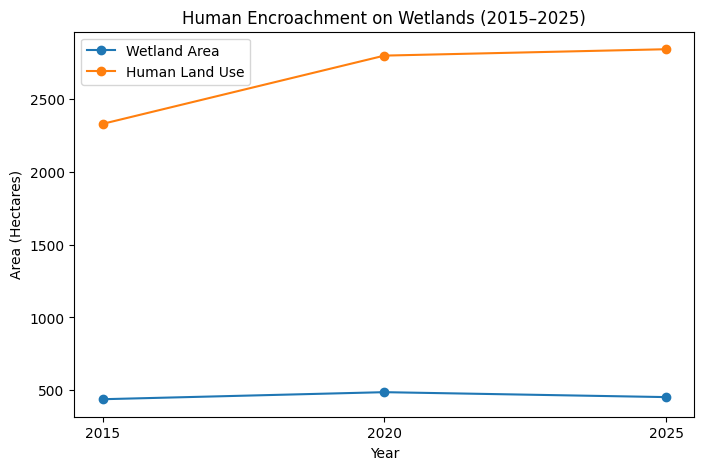

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('/content/LULC.csv')

# Convert to hectares
df['Area_ha'] = df['COUNT'] * 0.01

# Extract year
df['Year'] = df['YEAR'].str[:4]

# Define human land classes
human_classes = ['Built_up','Farmland','Tarmac/black_surfaces']

# Calculate totals
wetland = df[df['LANDCLASS']=='Wetland'].groupby('Year')['Area_ha'].sum()
human = df[df['LANDCLASS'].isin(human_classes)].groupby('Year')['Area_ha'].sum()

# Plot
plt.figure(figsize=(8,5))

plt.plot(wetland.index, wetland.values, marker='o', label='Wetland Area')
plt.plot(human.index, human.values, marker='o', label='Human Land Use')

plt.title('Human Encroachment on Wetlands (2015–2025)')
plt.xlabel('Year')
plt.ylabel('Area (Hectares)')
plt.legend()

plt.show()

Land Conversion Pressure Chart

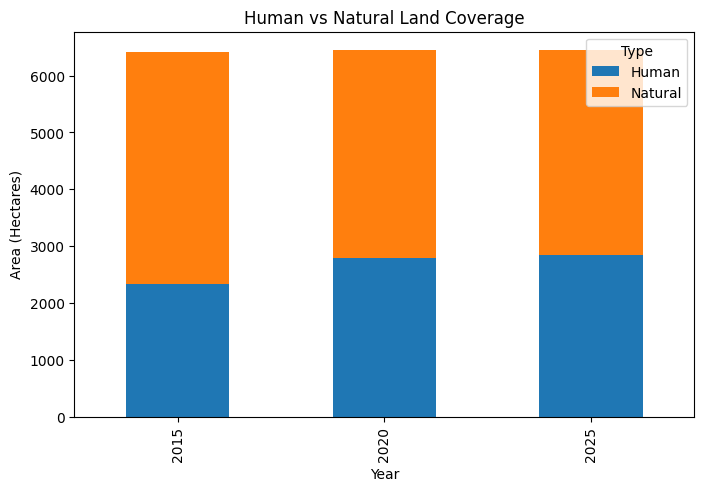

In [ ]:
# classify land types
df['Type'] = df['LANDCLASS'].replace({
    'Built_up':'Human',
    'Farmland':'Human',
    'Tarmac/black_surfaces':'Human',
    'Wetland':'Natural',
    'Vegetation':'Natural',
    'Open_water':'Natural',
    'Bareland':'Natural'
})

summary = df.groupby(['Year','Type'])['Area_ha'].sum().reset_index()

pivot = summary.pivot(index='Year', columns='Type', values='Area_ha')

pivot.plot(kind='bar', stacked=True, figsize=(8,5))

plt.title('Human vs Natural Land Coverage')
plt.ylabel('Area (Hectares)')
plt.xlabel('Year')

plt.show()

Wetland Encroachment Index (Very Powerful for Reports)

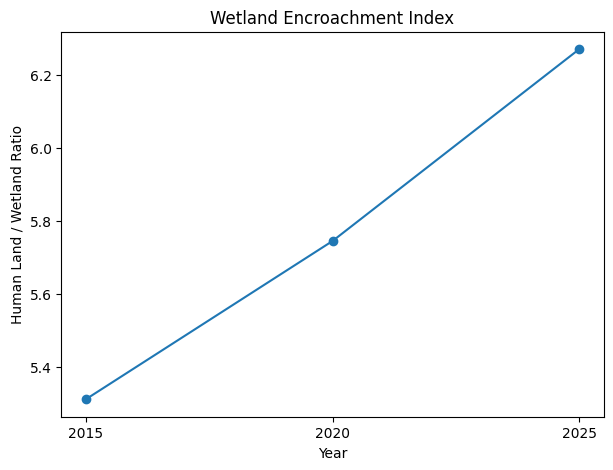

In [ ]:
encroachment_index = human / wetland

plt.figure(figsize=(7,5))

plt.plot(encroachment_index.index, encroachment_index.values, marker='o')

plt.title('Wetland Encroachment Index')
plt.xlabel('Year')
plt.ylabel('Human Land / Wetland Ratio')

plt.show()